In [15]:
import os
import pathlib
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

DATASET_URL = "http://download.tensorflow.org/data/speech_commands_v0.02.tar.gz"

download_path = tf.keras.utils.get_file(
    fname="speech_commands_v0.02.tar.gz",
    origin=DATASET_URL,
    extract=True,
    cache_dir=".",
    cache_subdir="data"
)

data_dir = pathlib.Path(download_path).parent

print("Download path:", download_path)
print("Data directory:", data_dir)
print("Folders:", [p.name for p in data_dir.iterdir() if p.is_dir()][:20])

2428923189/2428923189 ━━━━━━━━━━━━━━━━━━━━ 82s 0us/step
Download path: ./data/speech_commands_v0.02.tar.gz
Data directory: data
Folders: ['right', 'eight', 'cat', 'tree', 'backward', 'learn', 'bed', 'happy', 'go', 'dog', 'no', 'wow', 'follow', 'nine', 'left', 'stop', 'three', '_background_noise_', 'sheila', 'one']


In [16]:
commands = ["yes", "no", "up", "down"]

all_files = []

for command in commands:
    command_dir = data_dir / command
    files = list(command_dir.glob("*.wav"))
    print(command, "files found:", len(files))

    files = files[:300]
    all_files.extend([(str(file), command) for file in files])

np.random.shuffle(all_files)

print("Total audio files:", len(all_files))
print("Commands:", commands)

yes files found: 4044
no files found: 3941
up files found: 3723
down files found: 3917
Total audio files: 1200
Commands: ['yes', 'no', 'up', 'down']


In [17]:
def decode_audio(file_path):
    audio_binary = tf.io.read_file(file_path)
    audio, sample_rate = tf.audio.decode_wav(audio_binary)
    audio = tf.squeeze(audio, axis=-1)

    audio = audio[:16000]
    padding = tf.zeros([16000] - tf.shape(audio), dtype=tf.float32)
    audio = tf.concat([audio, padding], axis=0)

    return audio

Command: yes
Audio shape: (16000,)


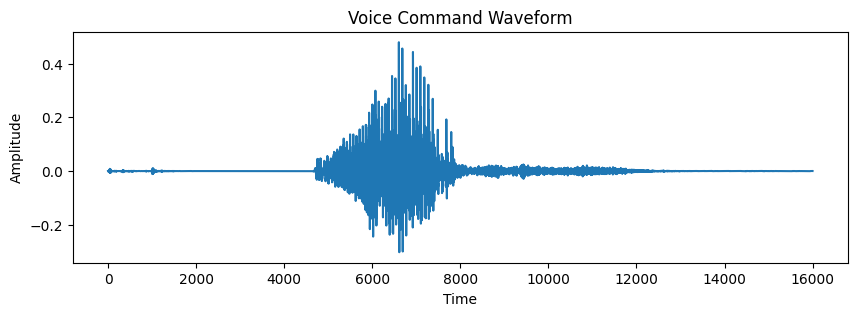

In [18]:
sample_file, sample_label = all_files[0]

sample_audio = decode_audio(sample_file)

print("Command:", sample_label)
print("Audio shape:", sample_audio.shape)

plt.figure(figsize=(10, 3))
plt.plot(sample_audio.numpy())
plt.title("Voice Command Waveform")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.show()

In [19]:
def get_spectrogram(audio):
    spectrogram = tf.signal.stft(
        audio,
        frame_length=255,
        frame_step=128
    )
    spectrogram = tf.abs(spectrogram)
    spectrogram = spectrogram[..., tf.newaxis]
    return spectrogram

Spectrogram shape: (124, 129, 1)


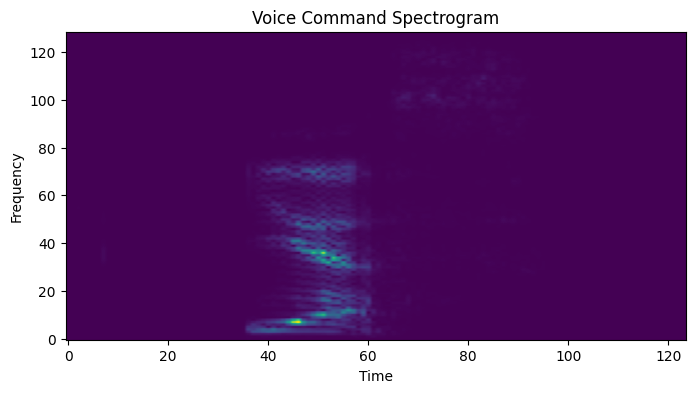

In [20]:
sample_spec = get_spectrogram(sample_audio)

print("Spectrogram shape:", sample_spec.shape)

plt.figure(figsize=(8, 4))
plt.imshow(sample_spec[:, :, 0].numpy().T, aspect="auto", origin="lower")
plt.title("Voice Command Spectrogram")
plt.xlabel("Time")
plt.ylabel("Frequency")
plt.show()

In [21]:
label_to_index = {label: index for index, label in enumerate(commands)}

X = []
y = []

for file_path, label in all_files:
    audio = decode_audio(file_path)
    spec = get_spectrogram(audio)

    X.append(spec.numpy())
    y.append(label_to_index[label])

X = np.array(X)
y = np.array(y)

print("Input shape:", X.shape)
print("Label shape:", y.shape)

Input shape: (1200, 124, 129, 1)
Label shape: (1200,)


In [22]:
split_index = int(0.8 * len(X))

X_train = X[:split_index]
y_train = y[:split_index]

X_test = X[split_index:]
y_test = y[split_index:]

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (960, 124, 129, 1)
Testing data: (240, 124, 129, 1)


In [23]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=X_train.shape[1:]),
    tf.keras.layers.Conv2D(16, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(32, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(len(commands), activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [24]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.4831 - loss: 1.2200 - val_accuracy: 0.6625 - val_loss: 0.9187
Epoch 2/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.7722 - loss: 0.6528 - val_accuracy: 0.7125 - val_loss: 0.8239
Epoch 3/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.8676 - loss: 0.4308 - val_accuracy: 0.7917 - val_loss: 0.8647
Epoch 4/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9253 - loss: 0.2412 - val_accuracy: 0.7333 - val_loss: 1.0928
Epoch 5/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9527 - loss: 0.1938 - val_accuracy: 0.8333 - val_loss: 0.8974


In [25]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print("Test Accuracy:", round(test_accuracy, 3))

Test Accuracy: 0.833


In [26]:
index = 5

prediction = model.predict(X_test[index:index+1])
predicted_label = commands[np.argmax(prediction)]
actual_label = commands[y_test[index]]

print("Predicted Command:", predicted_label)
print("Actual Command:", actual_label)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Predicted Command: down
Actual Command: down
